In [1]:
# library imports 
import pandas as pd 
from mlxtend.preprocessing import TransactionEncoder 
from mlxtend.frequent_patterns import apriori, association_rules

# Preparing the Transaction Data 

In [2]:
# The same 8 transactions used throughout this document 
dataset = [ 
['Bread', 'Milk'], 
['Bread', 'Diapers', 'Beer', 'Eggs'], 
['Milk', 'Diapers', 'Beer', 'Cola'], 
['Bread', 'Milk', 'Diapers', 'Beer'], 
['Bread', 'Milk', 'Diapers', 'Cola'], 
['Bread', 'Milk', 'Beer'], 
['Milk', 'Diapers', 'Cola'], 
['Bread', 'Milk', 'Diapers', 'Beer', 'Eggs'], 
] 
encoder = TransactionEncoder() 
encoded_array = encoder.fit(dataset).transform(dataset) 
df = pd.DataFrame(encoded_array, columns=encoder.columns_) 
print(df)

    Beer  Bread   Cola  Diapers   Eggs   Milk
0  False   True  False    False  False   True
1   True   True  False     True   True  False
2   True  False   True     True  False   True
3   True   True  False     True  False   True
4  False   True   True     True  False   True
5   True   True  False    False  False   True
6  False  False   True     True  False   True
7   True   True  False     True   True   True


# Mining Frequent Itemsets

In [3]:
# min_support = 0.375 reproduces the min_sup = 3/8 threshold from Section 3.3 
frequent_itemsets = apriori( 
    df, 
    min_support=0.375, 
    use_colnames=True 
) 
  
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len) 
frequent_itemsets = frequent_itemsets.sort_values( 
    by=['length', 'support'], ascending=[True, False] 
) 
print(frequent_itemsets) 

    support                itemsets  length
4     0.875                  (Milk)       1
1     0.750                 (Bread)       1
3     0.750               (Diapers)       1
0     0.625                  (Beer)       1
2     0.375                  (Cola)       1
9     0.625           (Milk, Bread)       2
12    0.625         (Milk, Diapers)       2
5     0.500           (Beer, Bread)       2
6     0.500         (Diapers, Beer)       2
7     0.500            (Milk, Beer)       2
8     0.500        (Diapers, Bread)       2
10    0.375         (Cola, Diapers)       2
11    0.375            (Milk, Cola)       2
13    0.375  (Diapers, Beer, Bread)       3
14    0.375     (Milk, Beer, Bread)       3
15    0.375   (Milk, Diapers, Beer)       3
16    0.375  (Milk, Diapers, Bread)       3
17    0.375   (Milk, Cola, Diapers)       3


# Generating Association Rules 

In [4]:
rules = association_rules( 
    frequent_itemsets, 
    metric='confidence', 
    min_threshold=0.6 
) 
  
rules = rules[['antecedents', 'consequents', 
               'support', 'confidence', 'lift']] 
rules = rules.sort_values(by='lift', ascending=False) 
print(rules.to_string(index=False)) 


     antecedents      consequents  support  confidence     lift
          (Cola)  (Milk, Diapers)    0.375    1.000000 1.600000
 (Milk, Diapers)           (Cola)    0.375    0.600000 1.600000
          (Cola)        (Diapers)    0.375    1.000000 1.333333
    (Milk, Cola)        (Diapers)    0.375    1.000000 1.333333
(Diapers, Bread)           (Beer)    0.375    0.750000 1.200000
          (Beer) (Diapers, Bread)    0.375    0.600000 1.200000
 (Cola, Diapers)           (Milk)    0.375    1.000000 1.142857
          (Cola)           (Milk)    0.375    1.000000 1.142857
       (Diapers)           (Beer)    0.500    0.666667 1.066667
         (Bread)           (Beer)    0.500    0.666667 1.066667
          (Beer)          (Bread)    0.500    0.800000 1.066667
          (Beer)        (Diapers)    0.500    0.800000 1.066667
    (Milk, Beer)        (Diapers)    0.375    0.750000 1.000000
 (Diapers, Beer)          (Bread)    0.375    0.750000 1.000000
   (Beer, Bread)        (Diapers)    0.3

# Filtering for High-Value Rules

In [5]:
strong_rules = rules[ 
    (rules['lift'] > 1.0) & 
    (rules['confidence'] >= 0.6) 
].sort_values(by=['lift', 'confidence'], ascending=False) 
  
print(strong_rules.to_string(index=False))

     antecedents      consequents  support  confidence     lift
          (Cola)  (Milk, Diapers)    0.375    1.000000 1.600000
 (Milk, Diapers)           (Cola)    0.375    0.600000 1.600000
          (Cola)        (Diapers)    0.375    1.000000 1.333333
    (Milk, Cola)        (Diapers)    0.375    1.000000 1.333333
(Diapers, Bread)           (Beer)    0.375    0.750000 1.200000
          (Beer) (Diapers, Bread)    0.375    0.600000 1.200000
 (Cola, Diapers)           (Milk)    0.375    1.000000 1.142857
          (Cola)           (Milk)    0.375    1.000000 1.142857
          (Beer)          (Bread)    0.500    0.800000 1.066667
          (Beer)        (Diapers)    0.500    0.800000 1.066667
       (Diapers)           (Beer)    0.500    0.666667 1.066667
         (Bread)           (Beer)    0.500    0.666667 1.066667


# Visualizing Rules (Optional)

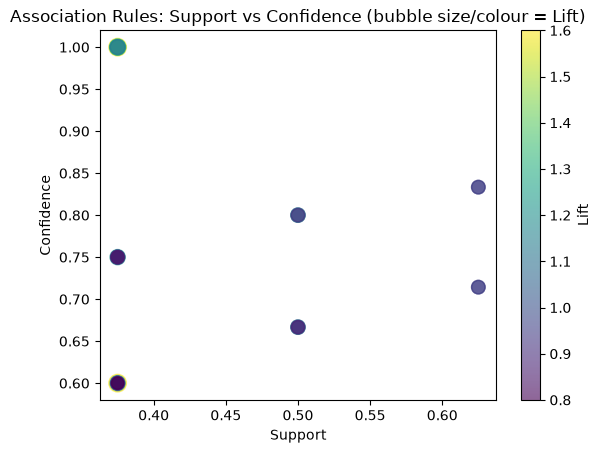

In [6]:
import matplotlib.pyplot as plt 
plt.scatter(rules['support'], rules['confidence'], 
s=rules['lift'] * 100, alpha=0.6, 
c=rules['lift'], cmap='viridis') 
plt.xlabel('Support') 
plt.ylabel('Confidence') 
plt.title('Association Rules: Support vs Confidence (bubble size/colour = Lift)') 
plt.colorbar(label='Lift') 
plt.show() 